*Churn modelling Analysis*

In [1]:
pip install nbformat

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pyodbc

*Load and read data*

In [3]:
df = pd.read_csv("Churn_Modelling.csv")

*View data*

In [4]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [7]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


****EDA****

In [8]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["Geography"].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [11]:
fig = px.pie(df,names="Geography",title="Country")
fig.show()

In [12]:
df['Age'].sort_index()

0       42
1       41
2       42
3       39
4       43
        ..
9995    39
9996    35
9997    36
9998    42
9999    28
Name: Age, Length: 10000, dtype: int64

In [13]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [14]:
fig = px.pie(df,names="Gender",title="Sex")
fig.show()

In [15]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

<Axes: >

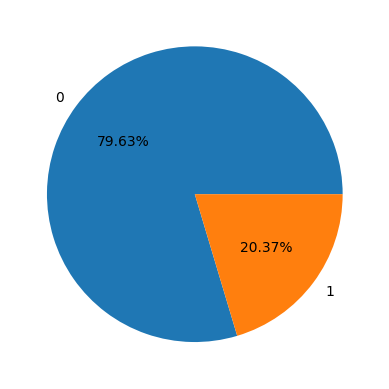

In [16]:
df['Exited'].value_counts().plot.pie(autopct='%.2f%%')

In [17]:
df.groupby('Geography')[['Gender','Exited','IsActiveMember']].sum()

,Gender,Exited,IsActiveMember
Geography,,,
France,FemaleFemaleFemaleMaleMaleMaleMaleFemaleFemale...,810,2591
Germany,FemaleMaleMaleMaleFemaleMaleMaleFemaleFemaleFe...,814,1248
Spain,FemaleFemaleMaleMaleFemaleFemaleMaleFemaleFema...,413,1312


In [18]:
# sns.pairplot(df,hue='Geography')

In [19]:
df.groupby('Gender')['Exited'].mean()

Gender
Female    0.250715
Male      0.164559
Name: Exited, dtype: float64

<Axes: ylabel='Gender'>

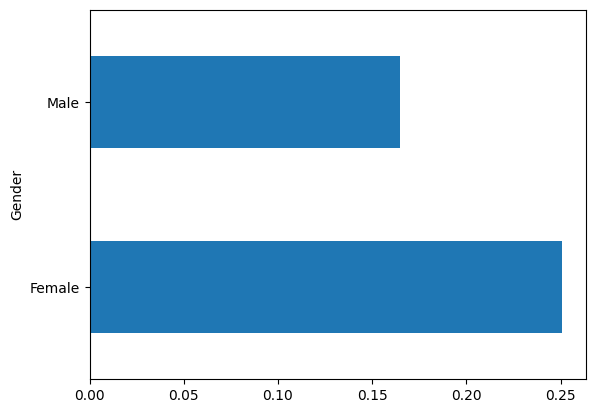

In [20]:
df.groupby('Gender')['Exited'].mean().plot(kind='barh')

In [21]:
df.groupby('Gender')['IsActiveMember'].mean()

Gender
Female    0.502751
Male      0.525380
Name: IsActiveMember, dtype: float64

<Axes: ylabel='Gender'>

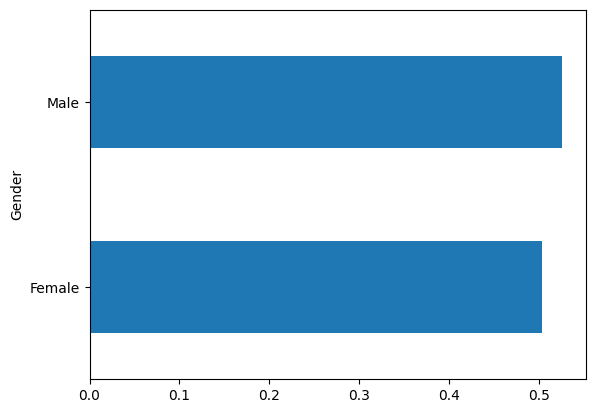

In [22]:
df.groupby('Gender')['IsActiveMember'].mean().plot(kind='barh')

In [23]:
df.groupby('Gender')['NumOfProducts'].mean()

Gender
Female    1.544134
Male      1.518600
Name: NumOfProducts, dtype: float64

In [24]:
px.histogram(df,x='NumOfProducts',y='Gender').show()

In [25]:
df.groupby('Gender')['HasCrCard'].mean()

Gender
Female    0.702619
Male      0.707898
Name: HasCrCard, dtype: float64

In [26]:
px.histogram(df,x='HasCrCard',y='Gender').show()

In [27]:
df.groupby('Geography')['HasCrCard'].mean()

Geography
France     0.706621
Germany    0.713830
Spain      0.694792
Name: HasCrCard, dtype: float64

In [28]:
px.histogram(df,x='HasCrCard',y='Geography').show()

In [29]:
df.groupby('Geography')['IsActiveMember'].mean()

Geography
France     0.516753
Germany    0.497409
Spain      0.529673
Name: IsActiveMember, dtype: float64

In [30]:
px.histogram(df,x='IsActiveMember',y='Geography').show()

In [31]:
df.groupby('Gender')['IsActiveMember'].mean()

Gender
Female    0.502751
Male      0.525380
Name: IsActiveMember, dtype: float64

In [32]:
px.histogram(df,x='IsActiveMember',y='Gender').show()

In [33]:
pd.crosstab(df['Geography'],df['Gender'])

Gender,Female,Male
Geography,,
France,2261,2753
Germany,1193,1316
Spain,1089,1388


<Axes: ylabel='Geography'>

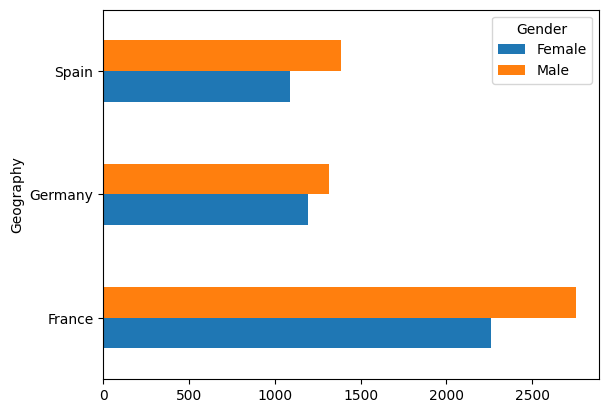

In [34]:
pd.crosstab(df['Geography'],df['Gender']).plot(kind='barh')

In [35]:
ct =pd.crosstab(df['Geography'],df['Gender'])
px.imshow(ct,text_auto=True).show()

🔍 Project Overview: Bank Customer Churn Analysis
This project performs a comprehensive Exploratory Data Analysis (EDA) on a dataset of 10,000 bank customers to identify patterns related to customer churn.

🛠️ Technical Approach:
Data Cleaning: Verified data integrity with zero null values and no duplicates.

Exploratory Data Analysis (EDA): Leveraged Pandas for statistical summaries and data manipulation.

Interactive Visualization: Used Plotly Express to create dynamic charts (Pie charts, Histograms, and Heatmaps) to visualize:

Geographic distribution (with France representing ~50% of the customer base).

Demographic insights like Age and Credit Score distributions.

Correlation between Gender and Geography using Cross-tabulation.

💡 Key Findings:
The dataset is well-balanced across genders and spans three main regions: France, Germany, and Spain.

Visualizing the interaction between variables highlights specific segments with higher churn potential, providing a solid foundation for building predictive models.